In [61]:
!kaggle datasets download -d saurabhshahane/cyberbullying-dataset

Dataset URL: https://www.kaggle.com/datasets/saurabhshahane/cyberbullying-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
cyberbullying-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [62]:
# prompt: unzip dataset

import zipfile
with zipfile.ZipFile('cyberbullying-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/kaggle/input/cyberbullying-dataset')


In [63]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


import re
import string
from wordcloud import WordCloud

from textblob import TextBlob

import nltk
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from collections import Counter
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
from sklearn.pipeline import Pipeline

import keras
import tensorflow as tf

import transformers
from transformers import (AutoTokenizer,
                          AutoModelForSequenceClassification,
                          TextClassificationPipeline)

import joblib
from tqdm import tqdm


In [64]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.optimizers import Adam


In [65]:
from scipy.sparse import csr_array, triu

In [66]:
data_twitter_parsed = pd.read_csv("/kaggle/input/cyberbullying-dataset/twitter_parsed_dataset.csv").drop(columns=['id', 'index', "oh_label"])
data_twitter_parsed.columns = ['text', 'Annotation']
data_twitter_parsed.head()

,text,Annotation
0,@halalflaws @biebervalue @greenlinerzjm I read...,none
1,@ShreyaBafna3 Now you idiots claim that people...,none
2,"RT @Mooseoftorment Call me sexist, but when I ...",sexism
3,"@g0ssipsquirrelx Wrong, ISIS follows the examp...",racism
4,#mkr No No No No No No,none


In [67]:
data_aggression_parsed = pd.read_csv("/kaggle/input/cyberbullying-dataset/aggression_parsed_dataset.csv").drop(columns=['index', 'ed_label_0', "ed_label_1"])
data_aggression_parsed.columns = ['text', 'oh_label']
data_aggression_parsed.head()

,text,oh_label
0,`- This is not ``creative``. Those are the di...,0
1,` :: the term ``standard model`` is itself le...,0
2,"True or false, the situation as of March 200...",0
3,"Next, maybe you could work on being less cond...",0
4,This page will need disambiguation.,0


In [68]:

data_aggression_parsed.rename(columns={"oh_label": "Annotation"}, inplace=True)


In [69]:

data_aggression_parsed["Annotation"] = data_aggression_parsed["Annotation"].replace({0: "none", 1: "aggression"})
data_aggression_parsed.head()

,text,Annotation
0,`- This is not ``creative``. Those are the di...,none
1,` :: the term ``standard model`` is itself le...,none
2,"True or false, the situation as of March 200...",none
3,"Next, maybe you could work on being less cond...",none
4,This page will need disambiguation.,none


In [70]:
data_attack_parsed = pd.read_csv("/kaggle/input/cyberbullying-dataset/attack_parsed_dataset.csv").drop(columns=['index', 'ed_label_0', "ed_label_1"])
data_attack_parsed.columns = ['text', 'oh_label']
data_attack_parsed.head()

,text,oh_label
0,`- This is not ``creative``. Those are the di...,0
1,` :: the term ``standard model`` is itself le...,0
2,"True or false, the situation as of March 200...",0
3,"Next, maybe you could work on being less cond...",0
4,This page will need disambiguation.,0


In [71]:

data_attack_parsed.rename(columns={"oh_label": "Annotation"}, inplace=True)
data_attack_parsed["Annotation"] = data_attack_parsed["Annotation"].replace({0: "none", 1: "attack"})
data_attack_parsed.head()

,text,Annotation
0,`- This is not ``creative``. Those are the di...,none
1,` :: the term ``standard model`` is itself le...,none
2,"True or false, the situation as of March 200...",none
3,"Next, maybe you could work on being less cond...",none
4,This page will need disambiguation.,none


In [72]:
data_kaggle_parsed = pd.read_csv("/kaggle/input/cyberbullying-dataset/kaggle_parsed_dataset.csv").drop(columns=['index', 'Date'])
data_kaggle_parsed.columns = ['Annotation', 'text']
data_kaggle_parsed.head()

,Annotation,text
0,1,"""You fuck your dad."""
1,0,"""i really don't understand your point.\xa0 It ..."
2,0,"""A\\xc2\\xa0majority of Canadians can and has ..."
3,0,"""listen if you dont wanna get married to a man..."
4,0,"""C\xe1c b\u1ea1n xu\u1ed1ng \u0111\u01b0\u1edd..."


In [73]:

data_kaggle_parsed = data_kaggle_parsed[['text', 'Annotation']]
data_kaggle_parsed.head()


,text,Annotation
0,"""You fuck your dad.""",1
1,"""i really don't understand your point.\xa0 It ...",0
2,"""A\\xc2\\xa0majority of Canadians can and has ...",0
3,"""listen if you dont wanna get married to a man...",0
4,"""C\xe1c b\u1ea1n xu\u1ed1ng \u0111\u01b0\u1edd...",0


In [74]:
data_kaggle_parsed["Annotation"] = data_kaggle_parsed["Annotation"].replace({0: "none", 1: "hate"})
data_kaggle_parsed.head()

,text,Annotation
0,"""You fuck your dad.""",hate
1,"""i really don't understand your point.\xa0 It ...",none
2,"""A\\xc2\\xa0majority of Canadians can and has ...",none
3,"""listen if you dont wanna get married to a man...",none
4,"""C\xe1c b\u1ea1n xu\u1ed1ng \u0111\u01b0\u1edd...",none


In [75]:
data_toxicity_parsed = pd.read_csv("/kaggle/input/cyberbullying-dataset/toxicity_parsed_dataset.csv").drop(columns=['index', 'ed_label_0', 'ed_label_1'])
data_toxicity_parsed.columns = ['text', 'Annotation']
data_toxicity_parsed.head()

,text,Annotation
0,This: :One can make an analogy in mathematical...,0
1,` :Clarification for you (and Zundark's righ...,0
2,Elected or Electoral? JHK,0
3,`This is such a fun entry. Devotchka I once...,0
4,Please relate the ozone hole to increases in c...,0


In [76]:
data_toxicity_parsed["Annotation"] = data_toxicity_parsed["Annotation"].replace({0: "none", 1: "toxic"})
data_toxicity_parsed.head()

,text,Annotation
0,This: :One can make an analogy in mathematical...,none
1,` :Clarification for you (and Zundark's righ...,none
2,Elected or Electoral? JHK,none
3,`This is such a fun entry. Devotchka I once...,none
4,Please relate the ozone hole to increases in c...,none


In [77]:
data_youtube_parsed = pd.read_csv("/kaggle/input/cyberbullying-dataset/youtube_parsed_dataset.csv").drop(columns=['index', 'UserIndex', 'Number of Comments', 'Number of Subscribers', 'Membership Duration', 'Number of Uploads', 'Profanity in UserID', 'Age'])
data_youtube_parsed.columns = ['text', 'Annotation']
data_youtube_parsed.head()

,text,Annotation
0,Does N.e.bodyelse Hear her Crazy ass Screamin ...,0
1,There are so many things that are incorrect wi...,0
2,3:26 hahah my boyfriend showed this song to me...,1
3,dick beyonce fuck y a ass hole you are truely ...,1
4,DongHaeTaemin and Kai ;A; luhansehun and bacon...,0


In [78]:
data_youtube_parsed["Annotation"] = data_youtube_parsed["Annotation"].replace({0: "none", 1: "hate"})
data_youtube_parsed.head()

,text,Annotation
0,Does N.e.bodyelse Hear her Crazy ass Screamin ...,none
1,There are so many things that are incorrect wi...,none
2,3:26 hahah my boyfriend showed this song to me...,hate
3,dick beyonce fuck y a ass hole you are truely ...,hate
4,DongHaeTaemin and Kai ;A; luhansehun and bacon...,none


In [79]:

import pandas as pd
data_combined = pd.concat([data_twitter_parsed, data_aggression_parsed, data_attack_parsed, data_kaggle_parsed, data_toxicity_parsed, data_youtube_parsed])
data_combined.head()


,text,Annotation
0,@halalflaws @biebervalue @greenlinerzjm I read...,none
1,@ShreyaBafna3 Now you idiots claim that people...,none
2,"RT @Mooseoftorment Call me sexist, but when I ...",sexism
3,"@g0ssipsquirrelx Wrong, ISIS follows the examp...",racism
4,#mkr No No No No No No,none


In [80]:
data_combined.shape

(420528, 2)

In [81]:

data_combined = data_combined.drop_duplicates(subset='text', keep='first')


In [82]:
data_combined.shape

(225349, 2)

In [83]:
data_combined['Annotation'].value_counts()

Annotation
none          200577
aggression     14764
sexism          3377
hate            3194
racism          1970
toxic           1464
Name: count, dtype: int64

In [84]:
import seaborn as sns

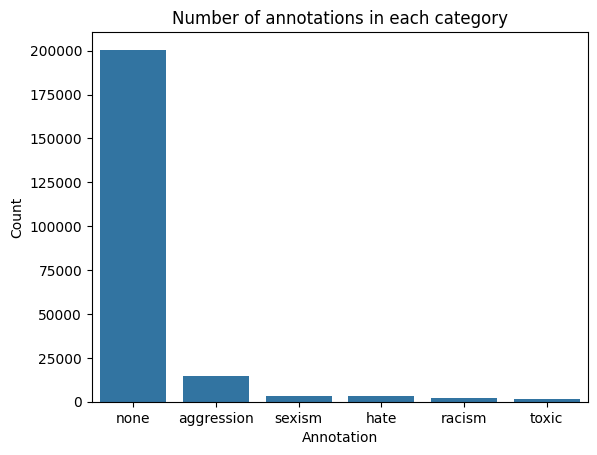

In [85]:

sns.barplot(x=data_combined['Annotation'].value_counts().index, y=data_combined['Annotation'].value_counts().values)
plt.xlabel('Annotation')
plt.ylabel('Count')
plt.title('Number of annotations in each category')
plt.show()


In [86]:
data_combined['text'] = data_combined['text'].fillna('')

In [87]:
def count_symbols(text):
    hashtag_count = len(re.findall(r'#', text))
    mention_count = len(re.findall(r'@', text))
    return hashtag_count, mention_count

# Apply the function to each row in the 'text' column
data_combined[['num_hashtags', 'num_mentions']] = data_combined['text'].apply(lambda x: pd.Series(count_symbols(x)))

data_combined.head()

,text,Annotation,num_hashtags,num_mentions
0,@halalflaws @biebervalue @greenlinerzjm I read...,none,0,3
1,@ShreyaBafna3 Now you idiots claim that people...,none,0,1
2,"RT @Mooseoftorment Call me sexist, but when I ...",sexism,0,1
3,"@g0ssipsquirrelx Wrong, ISIS follows the examp...",racism,0,1
4,#mkr No No No No No No,none,1,0


#**Data** **Cleaning**

In [88]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string
import re

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Lowercase conversion
def to_lowercase(text):
    return text.lower()

# Remove special characters and numbers
def remove_special_characters(text):
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'@\w+', '', text)     # remove mentions
    text = re.sub(r'#\w+', '', text)     # remove hashtags
    text = re.sub(r'\d+', '', text)      # remove numbers
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    return text

# Tokenization
def tokenize(text):
    return word_tokenize(text)

# Remove stopwords
def remove_stopwords(tokens):
    stop_words = set(stopwords.words('english'))
    return [word for word in tokens if word not in stop_words]

# Lemmatization
def lemmatize(tokens):
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(word) for word in tokens]

# Combine preprocessing steps
def preprocess_text(text):
    text = to_lowercase(text)
    text = remove_special_characters(text)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize(tokens)
    return ' '.join(tokens)




[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [89]:
# Apply preprocessing to the DataFrame
data_combined['cleaned_text'] = data_combined['text'].apply(preprocess_text)

# Display the cleaned DataFrame
print(data_combined[['text', 'cleaned_text', 'Annotation']])

KeyboardInterrupt: 

In [ ]:
data_combined.head()

,text,Annotation,num_hashtags,num_mentions,cleaned_text
0,@halalflaws @biebervalue @greenlinerzjm I read...,none,0,3,read contextno change meaning history islamic ...
1,@ShreyaBafna3 Now you idiots claim that people...,none,0,1,idiot claim people tried stop becoming terrori...
2,"RT @Mooseoftorment Call me sexist, but when I ...",sexism,0,1,rt call sexist go auto place id rather talk guy
3,"@g0ssipsquirrelx Wrong, ISIS follows the examp...",racism,0,1,wrong isi follows example mohammed quran exactly
4,#mkr No No No No No No,none,1,0,


# **Exploratory Data Analysis**

WordCloud

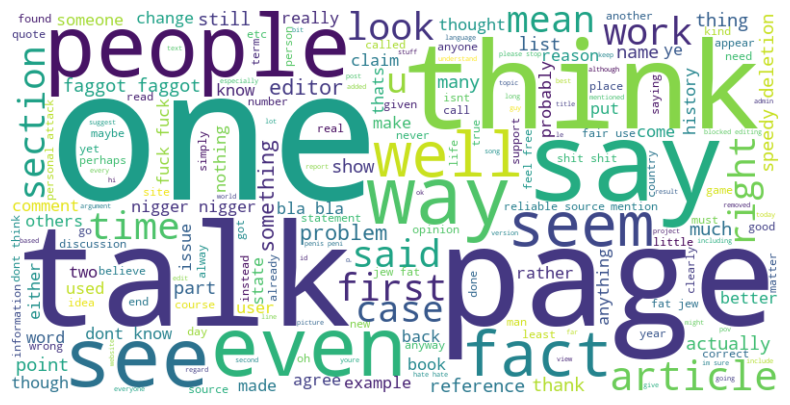

In [ ]:
from wordcloud import WordCloud

# Combine all cleaned text
all_text = ' '.join(data_combined['cleaned_text'])

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Plot word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


Top 20 Most Common Words

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


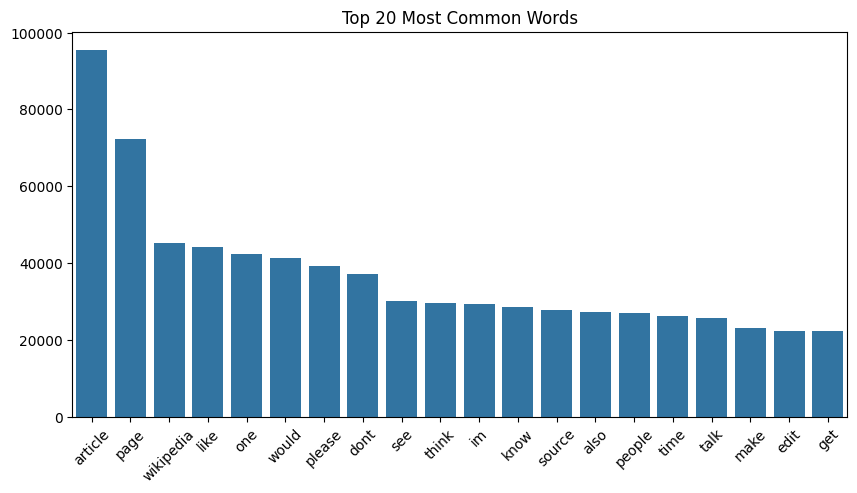

In [ ]:
from collections import Counter
import nltk
nltk.download('punkt')

# Tokenize and count words
tokens = nltk.word_tokenize(all_text)
word_freq = Counter(tokens)

# Most common words
common_words = word_freq.most_common(20)
words, counts = zip(*common_words)

# Plot word frequencies
plt.figure(figsize=(10, 5))
sns.barplot(x=list(words), y=list(counts))
plt.xticks(rotation=45)
plt.title('Top 20 Most Common Words')
plt.show()


In [ ]:
## Helper functions

def add_spines(colour = '#425169', linewidth = 2):
    """
    Add beautiful spines to you plots
    """
    ax = plt.gca()
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines[['bottom', 'left', 'top', 'right']].set_color(colour)
    ax.spines[['bottom', 'left', 'top', 'right']].set_linewidth(linewidth)

def roc_auc(predictions,target):
    '''
    This methods returns the AUC Score when given the Predictions
    and Labels
    '''

    fpr, tpr, thresholds = metrics.roc_curve(target, predictions)
    roc_auc = metrics.auc(fpr, tpr)
    return roc_auc

def bully_palette(df,column, positions_to_change: list):
    """
    A function to create grey red palettes according to the inputs
    You just need to pass in the dataframe and the index of labels to be highlighted in red
    """
    palette = ['#96898b']*df[column].nunique()
    new_values = ['#cc253b']*len(positions_to_change)
    for position, new_value in zip(positions_to_change, new_values):
        palette[position] = new_value
    return sns.color_palette(palette)


Sentiment Analyzer

In [ ]:
import nltk
nltk.download('vader_lexicon')


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
# Function to get sentiment of a text
def get_sentiment(text):
    compound_score = sia.polarity_scores(text)['compound']
    return 'positive' if compound_score >= 0 else 'negative'


data_combined['Sentiment_Label'] = data_combined['text'].apply(get_sentiment)

data_combined.head()

,text,Annotation,num_hashtags,num_mentions,cleaned_text,Sentiment_Label
0,@halalflaws @biebervalue @greenlinerzjm I read...,none,0,3,read contextno change meaning history islamic ...,negative
1,@ShreyaBafna3 Now you idiots claim that people...,none,0,1,idiot claim people tried stop becoming terrori...,negative
2,"RT @Mooseoftorment Call me sexist, but when I ...",sexism,0,1,rt call sexist go auto place id rather talk guy,positive
3,"@g0ssipsquirrelx Wrong, ISIS follows the examp...",racism,0,1,wrong isi follows example mohammed quran exactly,negative
4,#mkr No No No No No No,none,1,0,,negative


In [ ]:
## Extraction of the top ten mentions and hashtags in the dataset

# Function to extract hashtags from a text
def extract_hashtags(text):
    return re.findall(r'#\w+', text)

data_combined['Hashtags'] = data_combined['text'].apply(extract_hashtags)

# Function to extract hashtags from a text
def extract_mentions(text):
    return re.findall(r'@\w+', text)

data_combined['Mentions'] = data_combined['text'].apply(extract_mentions)

def create_counter_df(df):
    """
    Creates a dataframe that contains the Label and their count.
    Pass the dataframe containing the labels in the form of a list column as an input.
    Example usage:
    1. mentions = create_counter_df(df['Mentions'])
    2. sexist_mentions = create_counter_df(df[df.Annotation=='sexist']["Mentions"])
    """
    # Flatten the list of hashtags and count their occurrences
    all_counts = [tag for counts_list in df for tag in counts_list]
    label_counts = Counter(all_counts)

    # Create a DataFrame from the Counter dictionary
    counts_df = pd.DataFrame(list(label_counts.items()), columns=['Label', 'Count'])
    counts_df = counts_df.sort_values(by='Count', ascending=False)
    return counts_df

mentions_df = create_counter_df(data_combined['Mentions'])
top_10_mentions = mentions_df.head(10)
sexist_mentions = create_counter_df(data_combined[data_combined.Annotation=='sexism']["Mentions"])
top_10_sexist_mentions = sexist_mentions.head(10)
racist_mentions = create_counter_df(data_combined[data_combined.Annotation=='racism']["Mentions"])
top_10_racist_mentions = racist_mentions.head(10)
aggression_mentions = create_counter_df(data_combined[data_combined.Annotation=='aggression']["Mentions"])
top_10_aggression_mentions = aggression_mentions.head(10)
hate_mentions = create_counter_df(data_combined[data_combined.Annotation=='hate']["Mentions"])
top_10_hate_mentions = hate_mentions.head(10)
toxic_mentions = create_counter_df(data_combined[data_combined.Annotation=='toxic']["Mentions"])
top_10_toxic_mentions = toxic_mentions.head(10)


hashtags_df = create_counter_df(data_combined['Hashtags'])
top_10_hashtags = hashtags_df.head(10)
sexist_hashtags = create_counter_df(data_combined[data_combined.Annotation=='sexism']["Hashtags"])
top_10_sexist_hashtags = sexist_hashtags.head(10)
racist_hashtags = create_counter_df(data_combined[data_combined.Annotation=='racism']["Hashtags"])
top_10_racist_hashtags = racist_hashtags.head(10)
aggression_hashtags = create_counter_df(data_combined[data_combined.Annotation=='aggression']["Hashtags"])
top_10_aggression_hashtags = aggression_hashtags.head(10)
hate_hashtags = create_counter_df(data_combined[data_combined.Annotation=='hate']["Hashtags"])
top_10_hate_hashtags = hate_hashtags.head(10)
toxic_hashtags = create_counter_df(data_combined[data_combined.Annotation=='toxic']["Hashtags"])
top_10_toxic_hashtags = toxic_hashtags.head(10)



C:\Users\User\AppData\Local\Temp\ipykernel_19904\1307672500.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Label', y='Count', data=top_10_hashtags, palette='crest_r')
C:\Users\User\AppData\Local\Temp\ipykernel_19904\1307672500.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Label', y='Count', data=top_10_mentions, palette='flare_r')


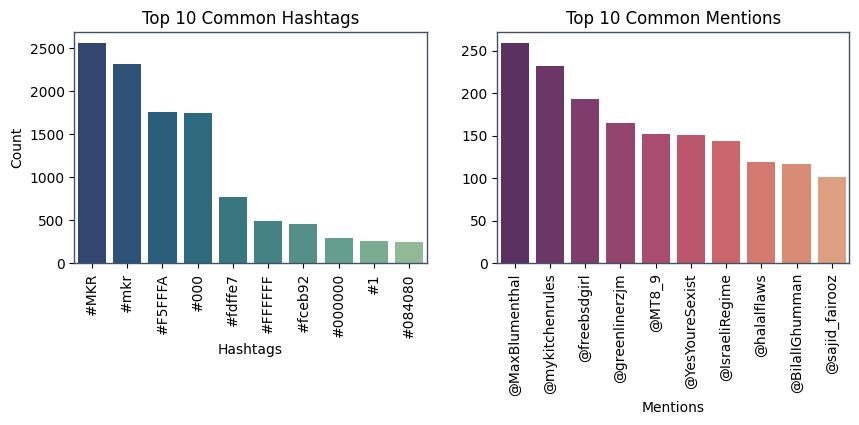

In [ ]:
plt.figure(figsize=(10, 3))

plt.subplot(121)
sns.barplot(x='Label', y='Count', data=top_10_hashtags, palette='crest_r')
plt.title('Top 10 Common Hashtags')
plt.xlabel('Hashtags')
plt.ylabel('Count')
plt.xticks(rotation=90)
add_spines(linewidth=1)

plt.subplot(122)
sns.barplot(x='Label', y='Count', data=top_10_mentions, palette='flare_r')
plt.title('Top 10 Common Mentions')
plt.xlabel('Mentions')
plt.ylabel('')
plt.xticks(rotation=90)
add_spines(linewidth=1)

C:\Users\User\AppData\Local\Temp\ipykernel_19904\3125458262.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Label', y='Count', data=top_10_sexist_hashtags, palette='crest_r')
C:\Users\User\AppData\Local\Temp\ipykernel_19904\3125458262.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Label', y='Count', data=top_10_sexist_mentions, palette='flare_r')
C:\Users\User\AppData\Local\Temp\ipykernel_19904\3125458262.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Label', y='Count', data=top_10_racist_hashtags, palette='crest_r')

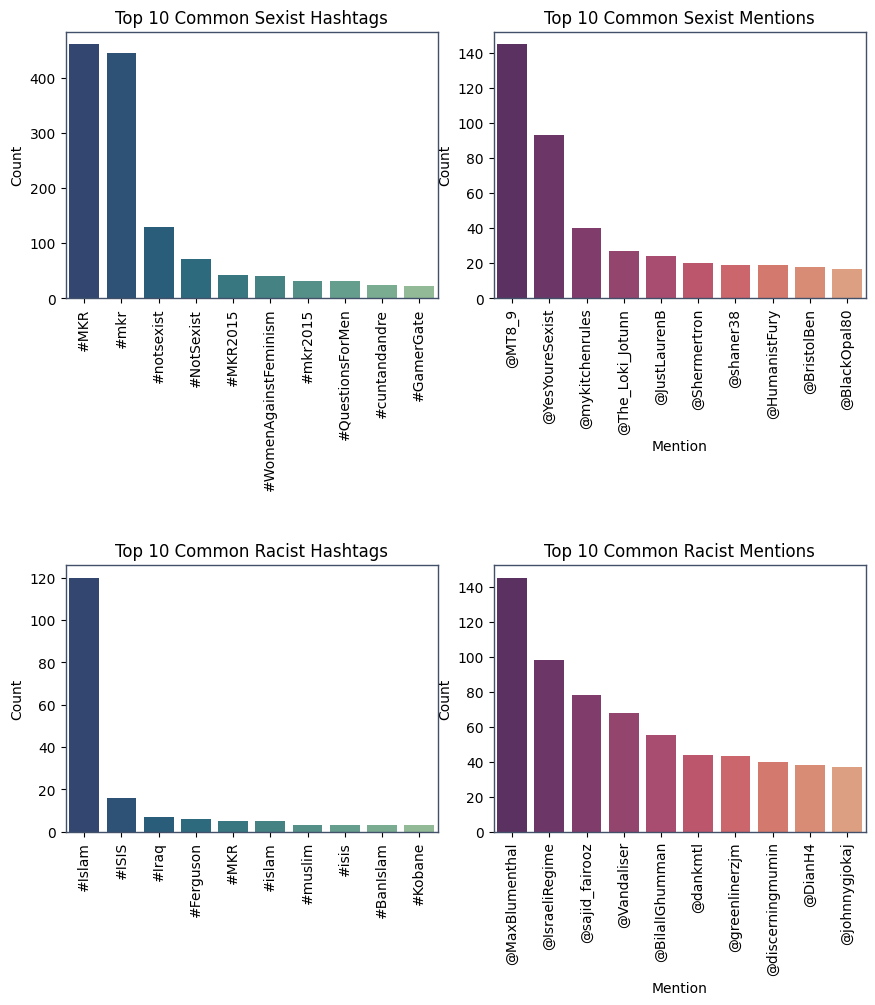

In [ ]:
plt.figure(figsize=(10, 10))

plt.subplot(221)
sns.barplot(x='Label', y='Count', data=top_10_sexist_hashtags, palette='crest_r')
plt.title('Top 10 Common Sexist Hashtags')
plt.xlabel('')
plt.ylabel('Count')
plt.xticks(rotation=90)
add_spines(linewidth=1)


plt.subplot(222)
sns.barplot(x='Label', y='Count', data=top_10_sexist_mentions, palette='flare_r')
plt.title('Top 10 Common Sexist Mentions')
plt.xlabel('Mention')
plt.ylabel('Count')
plt.xticks(rotation=90)
add_spines(linewidth=1)


plt.subplot(223)
sns.barplot(x='Label', y='Count', data=top_10_racist_hashtags, palette='crest_r')
plt.title('Top 10 Common Racist Hashtags')
plt.xlabel('')
plt.ylabel('Count')
plt.xticks(rotation=90)
add_spines(linewidth=1)


plt.subplot(224)
sns.barplot(x='Label', y='Count', data=top_10_racist_mentions, palette='flare_r')
plt.title('Top 10 Common Racist Mentions')
plt.xlabel('Mention')
plt.ylabel('Count')
plt.xticks(rotation=90)
add_spines(linewidth=1)


plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.15, hspace=1)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_19904\3456008495.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Label', y='Count', data=top_10_aggression_hashtags, palette='crest_r')
C:\Users\User\AppData\Local\Temp\ipykernel_19904\3456008495.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Label', y='Count', data=top_10_aggression_mentions, palette='flare_r')
C:\Users\User\AppData\Local\Temp\ipykernel_19904\3456008495.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Label', y='Count', data=top_10_toxic_hashtags, palette='cr

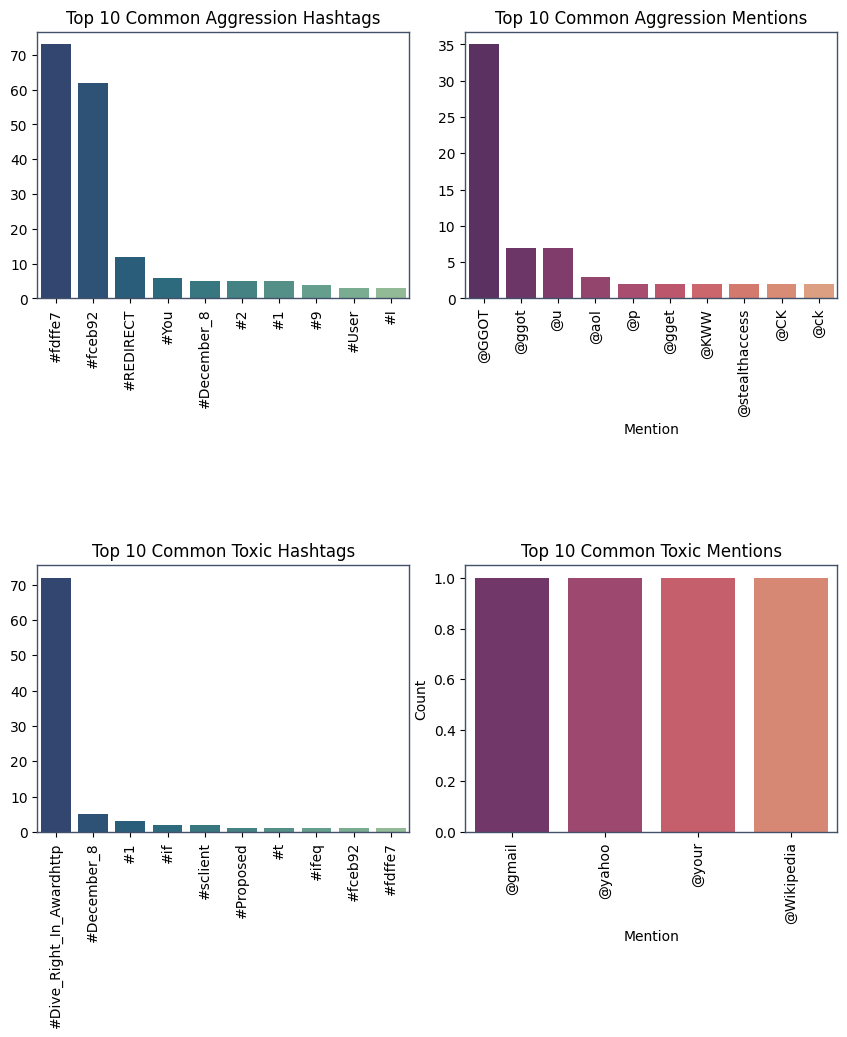

In [ ]:
plt.figure(figsize=(10, 10))

plt.subplot(221)
sns.barplot(x='Label', y='Count', data=top_10_aggression_hashtags, palette='crest_r')
plt.title('Top 10 Common Aggression Hashtags')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=90)
add_spines(linewidth=1)


plt.subplot(222)
sns.barplot(x='Label', y='Count', data=top_10_aggression_mentions, palette='flare_r')
plt.title('Top 10 Common Aggression Mentions')
plt.xlabel('Mention')
plt.ylabel('')
plt.xticks(rotation=90)
add_spines(linewidth=1)



plt.subplot(223)
sns.barplot(x='Label', y='Count', data=top_10_toxic_hashtags, palette='crest_r')
plt.title('Top 10 Common Toxic Hashtags')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=90)
add_spines(linewidth=1)


plt.subplot(224)
sns.barplot(x='Label', y='Count', data=top_10_toxic_mentions, palette='flare_r')
plt.title('Top 10 Common Toxic Mentions')
plt.xlabel('Mention')
plt.ylabel('Count')
plt.xticks(rotation=90)
add_spines(linewidth=1)



plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.15, hspace=1)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_19904\3575213462.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Label', y='Count', data=top_10_hate_hashtags, palette='crest_r')
C:\Users\User\AppData\Local\Temp\ipykernel_19904\3575213462.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Label', y='Count', data=top_10_hate_mentions, palette='flare_r')


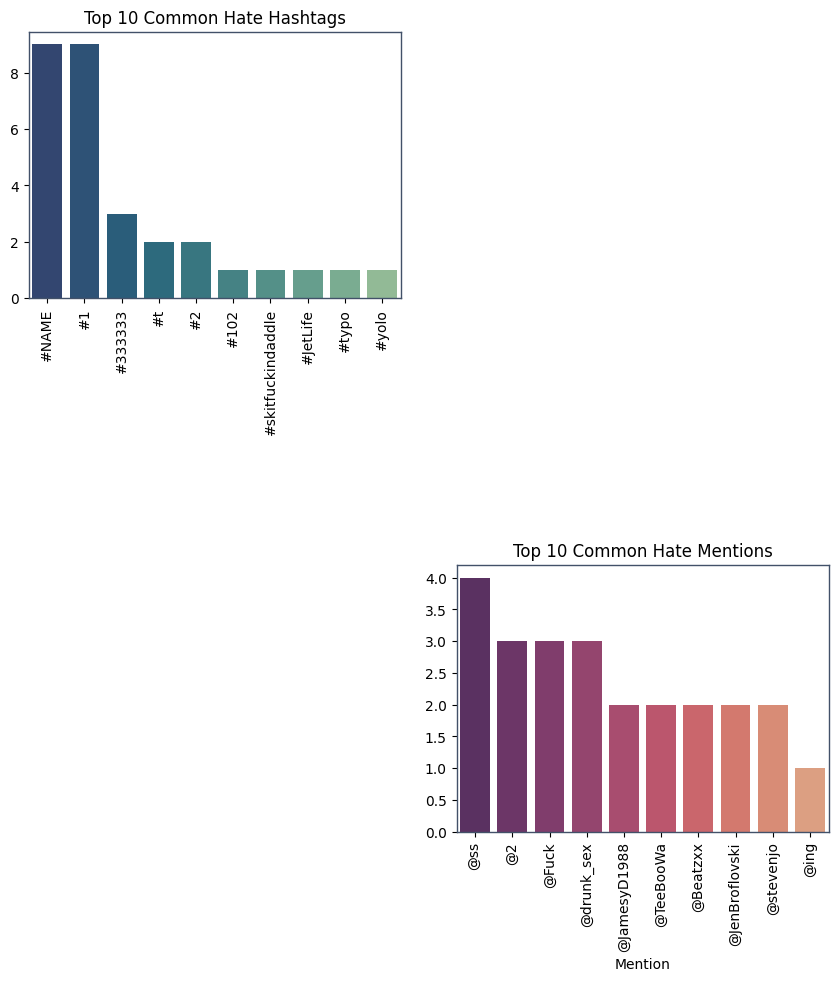

In [ ]:
plt.figure(figsize=(10, 10))

plt.subplot(221)
sns.barplot(x='Label', y='Count', data=top_10_hate_hashtags, palette='crest_r')
plt.title('Top 10 Common Hate Hashtags')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=90)
add_spines(linewidth=1)

plt.subplot(224)
sns.barplot(x='Label', y='Count', data=top_10_hate_mentions, palette='flare_r')
plt.title('Top 10 Common Hate Mentions')
plt.xlabel('Mention')
plt.ylabel('')
plt.xticks(rotation=90)
add_spines(linewidth=1)

plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.15, hspace=1)
plt.show()

# **Feature Extraction**

TF-IDF

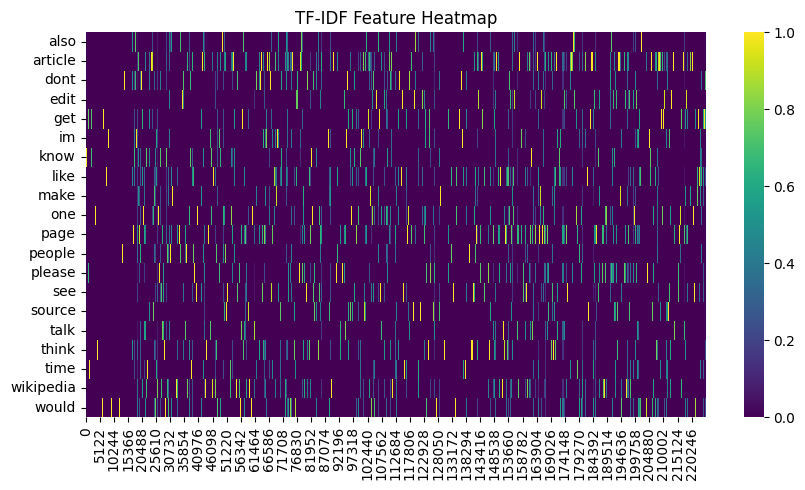

In [ ]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns

# Feature extraction using TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=20)
X = tfidf_vectorizer.fit_transform(data_combined['cleaned_text']).toarray()
feature_names = tfidf_vectorizer.get_feature_names_out()

# Create a DataFrame for the heatmap
tfidf_df = pd.DataFrame(X, columns=feature_names)

# Plot heatmap of TF-IDF features
plt.figure(figsize=(10, 5))
sns.heatmap(tfidf_df.T, cmap='viridis')
plt.title('TF-IDF Feature Heatmap')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob
import string

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Basic Feature

In [ ]:
def calculate_basic_features(text, features):
    features['word_count'] = len(word_tokenize(text))
    features['char_count'] = len(text)
    features['avg_word_length'] = np.mean([len(word) for word in word_tokenize(text)]) if len(word_tokenize(text)) > 0 else 0
    features['sentence_count'] = len(sent_tokenize(text))
    features['punctuation_count'] = len([char for char in text if char in string.punctuation])
    features['hashtag_count'] = len(re.findall(r'#\w+', text))
    features['mention_count'] = len(re.findall(r'@\w+', text))
    features['url_count'] = len(re.findall(r'http\S+', text))
    return features

# Apply the function to the DataFrame
data_combined['basic_features'] = data_combined['text'].apply(lambda x: calculate_basic_features(x, data_combined))


In [ ]:
def calculate_pos_tags(text):
    tokens = word_tokenize(text)
    pos_tags = pos_tag(tokens)
    pos_counts = nltk.FreqDist(tag for (word, tag) in pos_tags)
    return pos_counts

# Apply the function to the DataFrame
data_combined['pos_tags'] = data_combined['cleaned_text'].apply(lambda x: calculate_pos_tags(x))



In [ ]:
data_combined['pos_tags']

0                            {'JJ': 2, 'NN': 4, 'VBG': 1}
1       {'JJ': 4, 'NN': 3, 'NNS': 1, 'VBD': 2, 'VBG': ...
2                            {'NN': 8, 'VBP': 1, 'RB': 1}
3         {'JJ': 1, 'NN': 2, 'VBZ': 1, 'VBD': 1, 'RB': 2}
4                                                      {}
                              ...                        
3459    {'RB': 6, 'NN': 11, 'VBP': 3, 'JJ': 6, 'NNP': ...
3460               {'NN': 9, 'VBG': 1, 'WP': 1, 'VBP': 1}
3461    {'NN': 16, 'RBR': 1, 'VBP': 1, 'IN': 1, 'RB': ...
3462                                                   {}
3463    {'JJ': 17, 'NN': 61, 'VBP': 3, 'RB': 5, 'NNP':...
Name: pos_tags, Length: 225349, dtype: object

In [ ]:
data_combined.columns

Index(['text', 'Annotation', 'num_hashtags', 'num_mentions', 'cleaned_text',
       'Sentiment_Label', 'Hashtags', 'Mentions', 'word_count', 'char_count',
       'avg_word_length', 'sentence_count', 'punctuation_count',
       'hashtag_count', 'mention_count', 'url_count', 'basic_features',
       'pos_tags'],
      dtype='object')

In [ ]:
data_combined['Annotation'].value_counts()

Annotation
none          200577
aggression     14764
sexism          3377
hate            3194
racism          1970
toxic           1464
Name: count, dtype: int64

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
unique_pos_tags = set(tag for tags in data_combined['pos_tags'] for tag in tags.keys())

# Create columns for each POS tag with default value 0
for tag in unique_pos_tags:
    data_combined[f'pos_{tag}'] = 0

# Fill the columns with the counts from the dictionaries
for i, row in data_combined.iterrows():
    for tag, count in row['pos_tags'].items():
        data_combined.at[i, f'pos_{tag}'] = count

# Select features for X (excluding 'Annotation' and other non-numeric features)
features = ['num_hashtags', 'num_mentions', 'word_count', 'char_count', 'avg_word_length', 
            'sentence_count', 'punctuation_count', 'hashtag_count', 'mention_count', 'url_count']
pos_features = [f'pos_{tag}' for tag in unique_pos_tags]
X = data_combined[features + pos_features]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

# Convert annotations to a list of labels
data_combined['Annotation'] = data_combined['Annotation'].fillna('').astype(str)
data_combined['Annotation'] = data_combined['Annotation'].apply(lambda x: x.split(','))

# Use MultiLabelBinarizer to create a binary matrix for the annotations
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(data_combined['Annotation'])

# Split data into training and testing sets


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Initialize and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred, target_names=mlb.classes_))


              precision    recall  f1-score   support

                   0.00      0.00      0.00         1
  aggression       0.04      0.02      0.02      3069
        hate       0.00      0.00      0.00       602
        none       0.89      0.96      0.92     40110
      racism       0.05      0.00      0.00       386
      sexism       0.05      0.00      0.00       608
       toxic       0.00      0.00      0.00       294

   micro avg       0.86      0.85      0.86     45070
   macro avg       0.15      0.14      0.14     45070
weighted avg       0.80      0.85      0.82     45070
 samples avg       0.85      0.85      0.85     45070



C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [90]:
from sklearn.metrics import f1_score, accuracy_score


In [59]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Initialize the model
model = Sequential()
model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(len(mlb.classes_), activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Accuracy: {accuracy}')

# Make predictions
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Convert predictions to the original labels
y_pred_labels = mlb.inverse_transform(y_pred)

# Calculate Hamming loss and F1 score
from sklearn.metrics import hamming_loss, f1_score

h_loss = hamming_loss(y_test, y_pred)
print(f'Hamming Loss: {h_loss}')

f1 = f1_score(y_test, y_pred, average='micro')
print(f'F1 Score: {f1}')


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
4507/4507 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8751 - loss: 0.4233 - val_accuracy: 0.8876 - val_loss: 0.1214
Epoch 2/10
4507/4507 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8895 - loss: 0.1330 - val_accuracy: 0.8892 - val_loss: 0.1155
Epoch 3/10
4507/4507 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8895 - loss: 0.1155 - val_accuracy: 0.8897 - val_loss: 0.1111
Epoch 4/10
4507/4507 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.8908 - loss: 0.1094 - val_accuracy: 0.8897 - val_loss: 0.1098
Epoch 5/10
4507/4507 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8900 - loss: 0.1091 - val_accuracy: 0.8898 - val_loss: 0.1082
Epoch 6/10
4507/4507 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8908 - loss: 0.1073 - val_accuracy: 0.8896 - val_loss: 0.1101
Epoch 7/10
4507/4507 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8905 - loss: 0.1073 - val_accuracy: 0.8898 - val_loss: 0.1071
Epoch 8/10
4507/4507 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8908 - loss: 0.1063 -

In [92]:
from pycaret.classification import *

ModuleNotFoundError: No module named 'pycaret'

In [ ]:

# create a dataset using X_train and y_train
columns = []
dataset = np.column_stack((X_train, y_train))
for i in range(300):
    columns.append(str(i))
columns.append('Label')
auto_df = pd.DataFrame(dataset, columns=columns)

auto_df.head()

In [ ]:
from pycaret.classification import *
pycaret_automl = setup(data=auto_df, target = 'Annotations', session_id=42)

In [ ]:
best_model = compare_models()

In [ ]:
from sklearn.decomposition import PCA
from gensim.models import Word2Vec

# Tokenize and prepare data for Word2Vec
tokenized_text = data_combined['cleaned_text'].apply(lambda x: word_tokenize(x.lower()))

# Train Word2Vec model (you can also load a pre-trained model)
w2v_model = Word2Vec(sentences=tokenized_text, vector_size=100, window=5, min_count=1, workers=4)

# Function to get average Word2Vec embeddings for a text
def get_avg_w2v(text, model):
    words = word_tokenize(text.lower())
    vector = np.mean([model.wv[word] for word in words if word in model.wv], axis=0)
    return vector

# Apply the function to get embeddings
data_combined['w2v'] = data_combined['cleaned_text'].apply(lambda x: get_avg_w2v(x, w2v_model))
w2v_features = np.vstack(data_combined['w2v'])

# Combine with previous features
combined_features = pd.concat([combined_features, pd.DataFrame(w2v_features)], axis=1)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Define the label
y = data_combined['label']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(combined_features, y, test_size=0.2, random_state=42)

# Train a logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


In [ ]:
pip install lazypredict
pip install textstat
pip install gensim
pip install nltk
pip install textblob
pip install seaborn
pip install scikit-learn


In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob
import string
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')


In [ ]:
clf = LazyClassifier(ignore_warnings=True, random_state=42)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

# Print and visualize results
print(models)

plt.figure(figsize=(10, 5))
sns.barplot(x=models.index, y='Accuracy', data=models)
plt.xticks(rotation=90)
plt.title('Model Comparison')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Function to calculate evaluation metrics
def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return accuracy, precision, recall, f1

# Initialize list to store metrics
metrics = []

# Calculate metrics for each model
for model_name, model in clf.models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy, precision, recall, f1 = calculate_metrics(y_test, y_pred)
    metrics.append([model_name, accuracy, precision, recall, f1])

    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Create DataFrame for metrics
metrics_df = pd.DataFrame(metrics, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])

# Display metrics
print(metrics_df)
